# ADNI Alzheimer Disease vs Control from Predicted FreeSurfer Stats

ADNI-specific data loading plus the shared clinical stats workflow.

In [3]:
from __future__ import annotations

from pathlib import Path

import pandas as pd

from scalesurfer.experiments.clinical import (
    display_clinical_stats_workflow,
    run_clinical_stats_workflow,
)
from scalesurfer.experiments.clinical_datasets import (
    build_adni_classifier_bids_cohort,
    build_stats_model_df,
)
from scalesurfer.experiments.config import (
    CLINICAL_STATS_FEATURE_SOURCE,
    CLINICAL_STATS_FS_VERSION,
    CLINICAL_STATS_SEED,
    make_clinical_stats_workflow_config,
)

PROJECT_ROOT = Path("/home/rph/scalesurfer")
NOTEBOOK_DIR = PROJECT_ROOT / "docs/notebooks/03_inference"

FEATURE_SOURCE = CLINICAL_STATS_FEATURE_SOURCE
STATS_FS_VERSION = 6 # CLINICAL_STATS_FS_VERSION
SEED = CLINICAL_STATS_SEED

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 200)


In [11]:
ADNI_BIDS_DIR = PROJECT_ROOT / "data/adni_bids"
AD_CLASSIFIER_CSV = NOTEBOOK_DIR / "ad_classifier_6_11_2026.csv"
SUBJECTS_DIR = NOTEBOOK_DIR / "adni_clinical_subjects_fsv6"
OUTPUT_DIR = NOTEBOOK_DIR / "09_clinical_ad_outputs_fsv6"
OUTPUT_DIR.mkdir(exist_ok=True)

for path in [ADNI_BIDS_DIR, AD_CLASSIFIER_CSV]:
    if not path.exists():
        raise FileNotFoundError(path)

clinical_inputs, clinical_participants = build_adni_classifier_bids_cohort(
    bids_dir=ADNI_BIDS_DIR,
    classifier_csv=AD_CLASSIFIER_CSV,
    positive_groups=("AD",),
    negative_groups=("CN",),
    positive_name="AD",
    negative_name="CN",
)

BINARY_POSITIVE_LABEL = "AD"
BINARY_NEGATIVE_LABEL = "CN"

print(f"Found {len(clinical_inputs):,} ADNI AD/CN T1w image(s).")
print(clinical_participants["binary_label"].value_counts().rename_axis("group").to_string())


Found 1,435 ADNI AD/CN T1w image(s).
group
CN    1029
AD     406


## ScaleSurfer Inference

In [ ]:
RUN_SCALESURFER_INFERENCE = True

if RUN_SCALESURFER_INFERENCE:
    from scalesurfer import ScaleSurfer

    subjects = clinical_inputs["subject_id"].astype(str).tolist()
    images = clinical_inputs["image"].astype(str).tolist()
    surfer = ScaleSurfer(
        anat_files=images,
        subjects=subjects,
        subject_dir=SUBJECTS_DIR,
        batch_size=1,
        fs_version=STATS_FS_VERSION,
        volume_dtype="bfloat16",
        overwrite=True,
        n_jobs_cpu=-1,
        progress=True,
        verbose=True,
        async_writes=True,
        writer_backend="thread",
        writer_workers=8,
        writer_queue_size=32,
        inference_num_workers=8,
        prefetch_factor=8,
    )
    surfer.prepare_images()
    surfer.predict_volumes(
        batch_size=3,
        patch_chunk_size=None,
        write=True,
    )
    surfer.predict_stats(
        fs_version=STATS_FS_VERSION,
        batch_size=4,
        return_format="wide",
        write=True,
    )
    print(f"Predicted stats for {len(surfer.df_stats):,} subject(s).")
else:
    print("Set RUN_SCALESURFER_INFERENCE = True to prepare images, predict aparc+aseg, and predict stats.")

# [scalesurfer] prepare_images: 307.9s total, 4.66 img/s (0.2s/img) for 1435 subject(s)
# [scalesurfer] predict_volumes: 257.3s total, 5.58 img/s (0.2s/img) for 1435 subject(s)
# [scalesurfer] predict_stats: 418.9s total, 3.43 img/s (0.3s/img) for 1435 subject(s)

Conforming images:   0%|          | 0/1435 [00:00<?, ?it/s]

[scalesurfer] prepare_images: 307.9s total, 4.66 img/s (0.2s/img) for 1435 subject(s)
[scalesurfer] predict_volumes: async volume writes enabled backend=thread workers=8 queue_size=32


Predicting volumes:   0%|          | 0/479 [00:00<?, ?it/s]

[scalesurfer] predict_volumes: 257.3s total, 5.58 img/s (0.2s/img) for 1435 subject(s)


Predicting stats:   0%|          | 0/359 [00:00<?, ?it/s]

[scalesurfer] predict_stats: async stats writes enabled backend=thread workers=8 queue_size=32
[scalesurfer] predict_stats: 418.9s total, 3.43 img/s (0.3s/img) for 1435 subject(s)
Predicted stats for 1,435 subject(s).


In [13]:
model_df, feature_cols = build_stats_model_df(
    subjects_dir=SUBJECTS_DIR,
    clinical_inputs=clinical_inputs,
    clinical_participants=clinical_participants,
    fill_value=0.0,
    positive_label=BINARY_POSITIVE_LABEL,
    negative_label=BINARY_NEGATIVE_LABEL,
)

print(f"Feature source: {FEATURE_SOURCE}")
print(f"Rows: {len(model_df):,}")
print(f"Candidate features: {len(feature_cols):,}")


Feature source: scalesurfer_stats_predicted
Rows: 1,435
Candidate features: 795


In [14]:
EXPERIMENT_NAME = "adni_ad_vs_cn_stats"
DISEASE_CONTEXT = "Alzheimer's disease"
POSITIVE_LABEL_NAME = "AD"
NEGATIVE_LABEL_NAME = "CN"
AGE_COLS = ("age",)
SEX_COLS = ("sex",)
STUDY_COL = "site_id"
SCANNER_COLS = ("visit", "sequence_description", "image_type")
PROTOCOL_COLS = ()


In [15]:
analysis_df = model_df.copy()
analysis_feature_cols = [col for col in feature_cols if col in analysis_df.columns]

LABEL_COL = "y"
SUBJECT_COL = "subject"

print(f"Analysis table: {len(analysis_df):,} subjects x {len(analysis_feature_cols):,} candidate features")
print(analysis_df["binary_label"].value_counts().rename_axis("group").to_string())


Analysis table: 1,435 subjects x 795 candidate features
group
CN    1029
AD     406


## Shared Clinical Stats Workflow

Shared settings live in `scalesurfer/experiments/config.py`. The only dataset-specific
inputs below are the label names and covariate source columns. The workflow runs the
`features` and `residualized_features` scenarios, reports the active confounds, shows
performance, and lists the CSV outputs.


Dropped global model features: 64


Tuning C (inner CV):   0%|          | 0/200 [00:00<?, ?fit/s]

[adni_ad_vs_cn_stats] finished 2 scenario(s), 5 CV fold(s) each in 499.0s
Analysis table: 1,435 subjects x 731 selected features

Confounds used:
  continuous: ('age_years', 'aseg__global__eTIV')
  categorical: ('sex_canonical',)
  feature-derived: ('aseg__global__eTIV',)
  encoded terms: 4

OOF performance:


,scenario,n,auc,average_precision,balanced_accuracy,f1,selected_c
0,features,1435,0.943328,0.895601,0.868478,0.797674,NaN
1,residualized_features,1435,0.911277,0.859897,0.838084,0.755196,NaN



Holdout performance:


,scenario,n,auc,average_precision,balanced_accuracy,f1,selected_c
0,features,287,0.943545,0.903266,0.857545,0.792683,10.0
1,residualized_features,287,0.876244,0.813301,0.787636,0.690476,1.0



CSV outputs:
  model_rows: /home/rph/scalesurfer/docs/notebooks/03_inference/09_clinical_ad_outputs_fsv6/scalesurfer_stats_predicted_model_rows.csv
  cv_metrics: /home/rph/scalesurfer/docs/notebooks/03_inference/09_clinical_ad_outputs_fsv6/scalesurfer_stats_predicted_cv_metrics.csv
  cv_scores: /home/rph/scalesurfer/docs/notebooks/03_inference/09_clinical_ad_outputs_fsv6/scalesurfer_stats_predicted_cv_scores.csv
  oof_metrics: /home/rph/scalesurfer/docs/notebooks/03_inference/09_clinical_ad_outputs_fsv6/scalesurfer_stats_predicted_oof_metrics.csv
  oof_predictions: /home/rph/scalesurfer/docs/notebooks/03_inference/09_clinical_ad_outputs_fsv6/scalesurfer_stats_predicted_oof_predictions.csv
  holdout_metrics: /home/rph/scalesurfer/docs/notebooks/03_inference/09_clinical_ad_outputs_fsv6/scalesurfer_stats_predicted_holdout_metrics.csv
  logreg_coefficients: /home/rph/scalesurfer/docs/notebooks/03_inference/09_clinical_ad_outputs_fsv6/scalesurfer_stats_predicted_logreg_coefficients.csv
  f

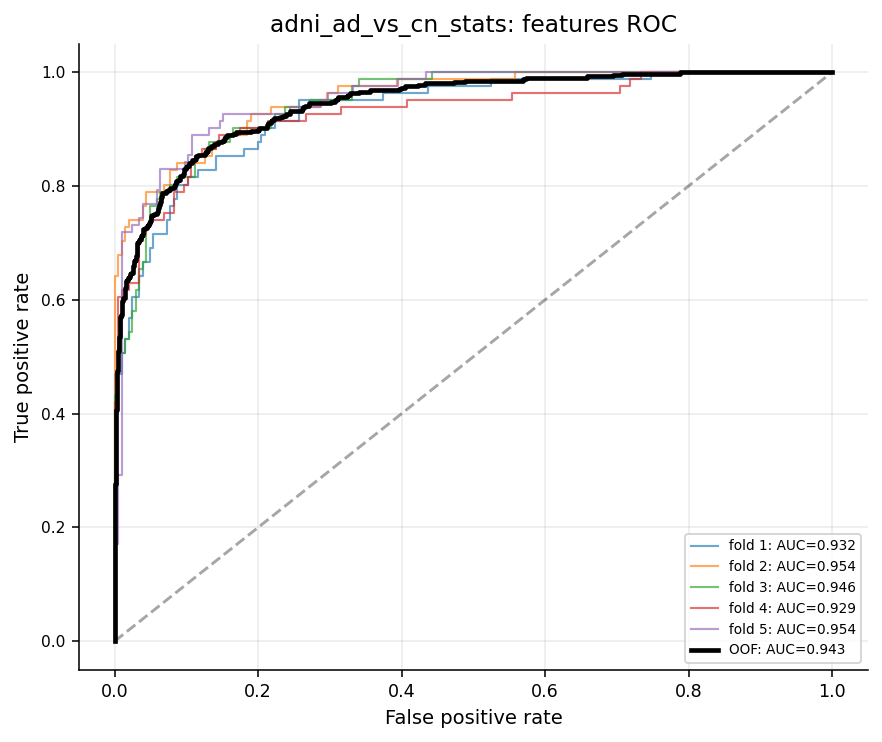

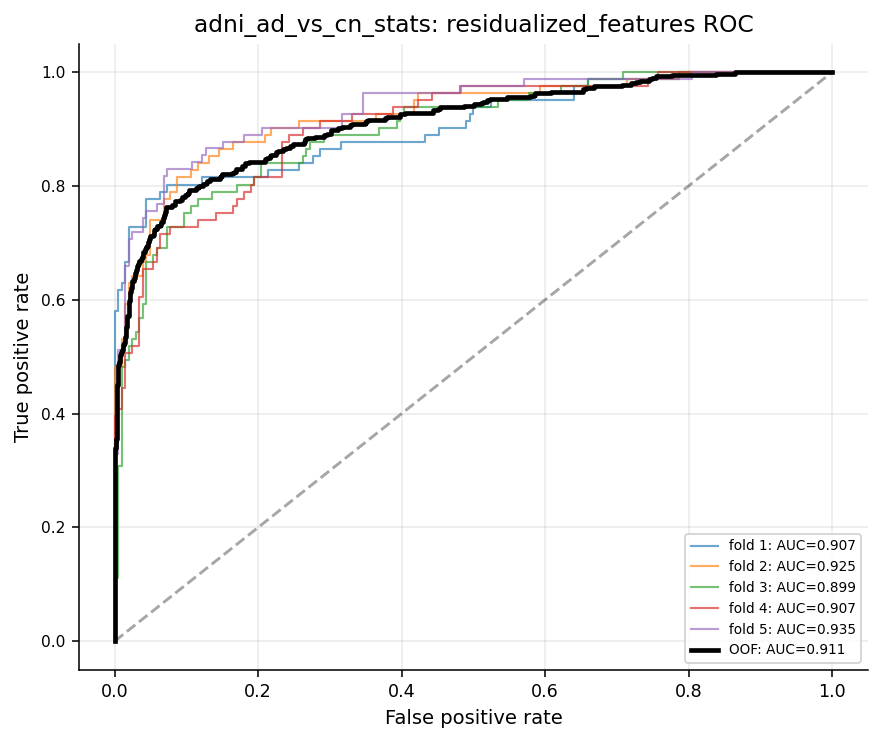

In [41]:
workflow_config = make_clinical_stats_workflow_config(
    experiment_name=EXPERIMENT_NAME,
    output_dir=OUTPUT_DIR,
    disease_context=DISEASE_CONTEXT,
    positive_label_name=POSITIVE_LABEL_NAME,
    negative_label_name=NEGATIVE_LABEL_NAME,
    age_cols=AGE_COLS,
    sex_cols=SEX_COLS,
    study_col=STUDY_COL,
    scanner_cols=SCANNER_COLS,
    protocol_cols=PROTOCOL_COLS,
)

# Conservative AD analysis: do not model global size/QC summaries as disease features.
global_feature_cols = tuple(col for col in analysis_feature_cols if "__global__" in col)
other_drop = (
    "__global__",              # eTIV, BrainSegVol, global QC/size summaries
    "SurfaceHoles",            # QC/reconstruction failure-ish
    "5th-Ventricle",           # tiny/unreliable
    "Left-vessel",
    "Right-vessel",
    "Optic-Chiasm",            # tiny/sensitive; previously suspicious
    "WM-hypointensities",      # vascular/QC/age burden, not AD-specific morphometry
    "non-WM-hypointensities",
)
analysis_feature_cols = [col for col in analysis_feature_cols if col not in set(global_feature_cols) and col not in other_drop]

print(f"Dropped global model features: {len(global_feature_cols):,}")

workflow = run_clinical_stats_workflow(
    analysis_df,
    analysis_feature_cols,
    workflow_config,
    label_col=LABEL_COL,
    subject_col=SUBJECT_COL,
)
clinical_result = workflow.result

cv_metrics = clinical_result.cv_metrics
oof_metrics = clinical_result.oof_metrics
holdout_metrics = clinical_result.holdout_metrics
cv_scores = clinical_result.cv_scores
oof_predictions = clinical_result.oof_predictions
c_table = clinical_result.c_table
output_paths = clinical_result.output_paths

display_clinical_stats_workflow(workflow)


In [42]:
coef_df = clinical_result.feature_importance
coef_df.head(50)

,scenario,feature,coef,coef_std,abs_coef,abs_coef_std,sign_consistency,n_folds,source,family,region,measure,hemi,literature_relevance
0,features,aseg__Right-Inf-Lat-Vent__Volume_mm3,4.736798,0.314593,4.736798,0.314593,1.0,5,aseg,aseg,Right-Inf-Lat-Vent,Volume_mm3,rh,AD literature-consistent
1,features,aseg__Left-Hippocampus__Volume_mm3,-3.358713,0.226363,3.358713,0.226363,1.0,5,aseg,aseg,Left-Hippocampus,Volume_mm3,lh,AD literature-consistent
2,features,wmparc__wm-lh-entorhinal__Volume_mm3,-2.946406,0.324976,2.946406,0.324976,1.0,5,wmparc,wmparc,wm-lh-entorhinal,Volume_mm3,lh,AD literature-consistent
3,features,aseg__Right-Hippocampus__Volume_mm3,-2.778958,0.324167,2.778958,0.324167,1.0,5,aseg,aseg,Right-Hippocampus,Volume_mm3,rh,AD literature-consistent
4,features,lh.aparc__precuneus__FoldInd,-2.416829,0.302518,2.416829,0.302518,1.0,5,lh.aparc,lh,precuneus,FoldInd,lh,AD literature-consistent
5,features,aseg__Left-Cerebellum-Cortex__Volume_mm3,2.200780,0.174419,2.200780,0.174419,1.0,5,aseg,aseg,Left-Cerebellum-Cortex,Volume_mm3,lh,not pre-specified
6,features,lh.aparc__rostralmiddlefrontal__FoldInd,2.062718,0.456851,2.062718,0.456851,1.0,5,lh.aparc,lh,rostralmiddlefrontal,FoldInd,lh,not pre-specified
7,features,aseg__Left-Inf-Lat-Vent__Volume_mm3,2.003718,0.234293,2.003718,0.234293,1.0,5,aseg,aseg,Left-Inf-Lat-Vent,Volume_mm3,lh,AD literature-consistent
8,features,lh.aparc__caudalanteriorcingulate__SurfArea,1.966434,0.245939,1.966434,0.245939,1.0,5,lh.aparc,lh,caudalanteriorcingulate,SurfArea,lh,not pre-specified
9,features,aseg__Right-choroid-plexus__Volume_mm3,-1.905842,0.334287,1.905842,0.334287,1.0,5,aseg,aseg,Right-choroid-plexus,Volume_mm3,rh,not pre-specified


## Summary Figure

OOF model performance and interpretability summary for the residualized clinical-stats scenario.


In [ ]:
import textwrap

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

PUBLICATION_FIG_DIR = OUTPUT_DIR
plot_scenario = "features"
if plot_scenario not in set(oof_predictions["scenario"].astype(str)):
    plot_scenario = str(oof_predictions["scenario"].iloc[0])

plot_df = oof_predictions.loc[oof_predictions["scenario"].eq(plot_scenario)].copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["y", "score", "pred"])
y_true = plot_df["y"].astype(int).to_numpy()
y_score = plot_df["score"].astype(float).to_numpy()
y_pred = plot_df["pred"].astype(int).to_numpy()

auc = roc_auc_score(y_true, y_score)
ap = average_precision_score(y_true, y_score)
bal_acc = balanced_accuracy_score(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)
fpr, tpr, _ = roc_curve(y_true, y_score)

importance = coef_df.loc[coef_df["scenario"].eq(plot_scenario)].copy()
importance = importance.replace([np.inf, -np.inf], np.nan).dropna(subset=["feature", "coef", "abs_coef"])
importance = importance.sort_values("abs_coef", ascending=False).head(20).iloc[::-1]

# importance['feature'] = [
#     "R. Cerebellum WM | Volume",
#     "L. Lingual | Fold Index",
#     "L. Parahippocampal | Fold Index",
#     "L. Pericalcarine | Fold Index",
#     "L. Cerebellum Cortex | Volume",
#     "L. Amygdala | Volume",
#     "R. Transverse Temporal WM | Volume",
#     "L. Pallidum | Volume",
#     "R. Lateral Orbitofrontal WM | Volume",
#     "L. Insula WM | Volume",
#     "L. Entorhinal WM | Volume",
#     "R. Amygdala | Volume",
#     "R. Isthmus Cingulate | Fold Index",
#     "R. Hippocampus | Volume",
#     "L. Caudal Anterior Cingulate | Surface Area",
#     "L. Hippocampus | Volume",
#     "R. Choroid Plexus | Volume",
#     "L. Supramarginal | Gray Matter Volume",
#     "L. Middle Temporal WM | Volume",
#     "R. Inferior Lateral Ventricle | Volume",
# ]
importance['feature'] = [
    "L. Cuneus | Thickness Std.",
    "R. Entorhinal | Num. Vertices",
    "L. Parahippocampal | Fold Index",
    "L. Frontal Pole | Fold Index",
    "R. Transverse Temporal WM | Volume",
    "L. Supramarginal | Gray Matter Volume",
    "L. Lingual | Fold Index",
    "L. Amygdala | Volume",
    "L. Inferior Temporal | Num. Vertices",
    "L. Middle Temporal WM | Volume",
    "R. Choroid Plexus | Volume",
    "L. Caudal Ant. Cingulate | Surf. Area",
    "L. Inferior Lateral Ventricle | Volume",
    "L. Rostral Middle Frontal | Fold Index",
    "L. Cerebellum Cortex | Volume",
    "L. Precuneus | Fold Index",
    "R. Hippocampus | Volume",
    "L. Entorhinal WM | Volume",
    "L. Hippocampus | Volume",
    "R. Inferior Lateral Ventricle | Volume",
]

saved /home/rph/scalesurfer/docs/notebooks/03_inference/09_clinical_ad_outputs_fsv6/scalesurfer_stats_predicted_features_publication_summary.png
saved /home/rph/scalesurfer/docs/notebooks/03_inference/09_clinical_ad_outputs_fsv6/scalesurfer_stats_predicted_features_publication_summary.svg


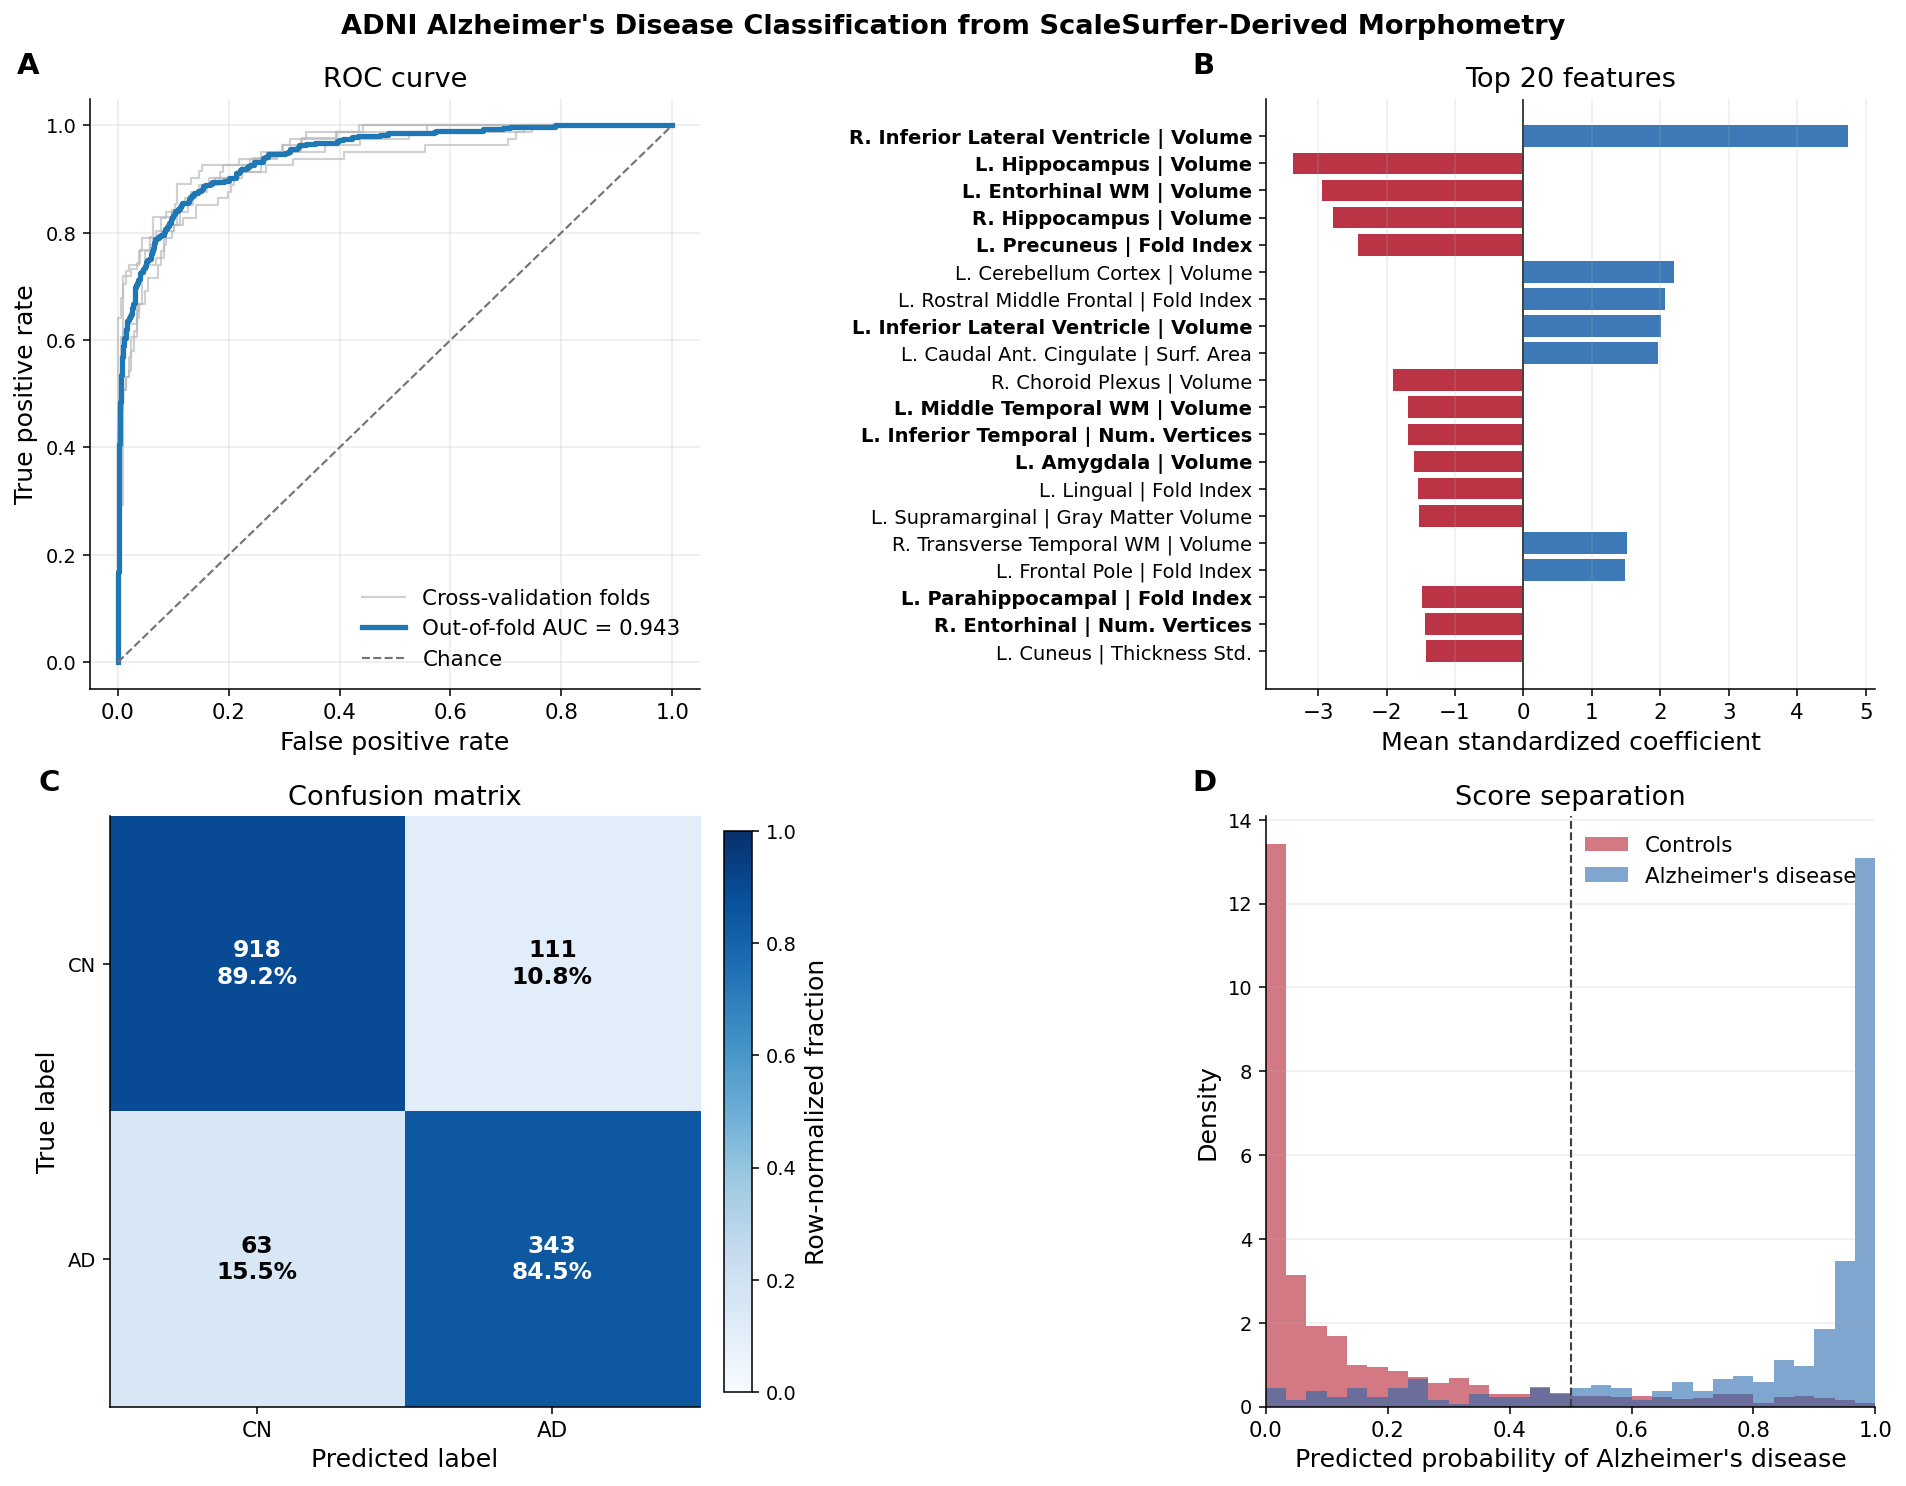

In [99]:
def _feature_label(value, width=38):
    text = str(value).replace("__", " | ").replace("_", " ")
    return "\n".join(textwrap.wrap(text, width=width, break_long_words=False))

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 10,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, axes = plt.subplots(2, 2, figsize=(13.5, 10.5), constrained_layout=True)
ax_roc, ax_imp, ax_cm, ax_hist = axes.ravel()

# A. ROC curve
cv_plot_df = cv_scores.loc[cv_scores["scenario"].eq(plot_scenario)].copy()
cv_plot_df = cv_plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["fold", "y", "score"])
for i, (_, fold_df) in enumerate(cv_plot_df.groupby("fold", sort=True)):
    if fold_df["y"].nunique() < 2:
        continue
    fold_fpr, fold_tpr, _ = roc_curve(fold_df["y"].astype(int), fold_df["score"].astype(float))
    ax_roc.plot(fold_fpr, fold_tpr, color="0.72", linewidth=1.1, alpha=0.65, label="Cross-validation folds" if i == 0 else None)
ax_roc.plot(fpr, tpr, color="#1f77b4", linewidth=2.7, label=f"Out-of-fold AUC = {auc:.3f}")
ax_roc.plot([0, 1], [0, 1], color="0.45", linestyle="--", linewidth=1.1, label="Chance")
# ax_roc.set_xlim(0, 1)
# ax_roc.set_ylim(0, 1.02)
ax_roc.set_xlabel("False positive rate")
ax_roc.set_ylabel("True positive rate")
ax_roc.set_title("ROC curve")
ax_roc.grid(True, alpha=0.25)
ax_roc.legend(loc="lower right", frameon=False)
ax_roc.text(-0.12, 1.08, "A", transform=ax_roc.transAxes, fontsize=15, fontweight="bold", va="top")

# B. Feature importance
colors = np.where(importance["coef"].to_numpy() >= 0, "#2166ac", "#b2182b")
pretty_labels = [_feature_label(v) for v in importance["feature"]]
ax_imp.barh(np.arange(len(importance)), importance["coef"].to_numpy(), color=colors, alpha=0.88)
ax_imp.axvline(0, color="0.25", linewidth=1.0)
ax_imp.set_yticks(np.arange(len(importance)))
ax_imp.set_yticklabels(pretty_labels)
for tick, relevance in zip(ax_imp.get_yticklabels(), importance["literature_relevance"].astype(str)):
    if relevance != "not pre-specified":
        tick.set_fontweight("bold")
ax_imp.set_xlabel("Mean standardized coefficient")
ax_imp.set_title("Top 20 features")
ax_imp.grid(axis="x", alpha=0.22)
ax_imp.text(-0.12, 1.08, "B", transform=ax_imp.transAxes, fontsize=15, fontweight="bold", va="top")

# C. Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
cm_pct = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
im = ax_cm.imshow(cm_pct, cmap="Blues", vmin=0, vmax=1)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = "white" if cm_pct[i, j] > 0.55 else "black"
        ax_cm.text(j, i, f"{cm[i, j]:,}\n{cm_pct[i, j]:.1%}", ha="center", va="center", color=text_color, fontweight="bold")
ax_cm.set_xticks([0, 1], [NEGATIVE_LABEL_NAME, POSITIVE_LABEL_NAME])
ax_cm.set_yticks([0, 1], [NEGATIVE_LABEL_NAME, POSITIVE_LABEL_NAME])
ax_cm.set_xlabel("Predicted label")
ax_cm.set_ylabel("True label")
ax_cm.set_title(f"Confusion matrix")
fig.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04, label="Row-normalized fraction")
ax_cm.text(-0.12, 1.08, "C", transform=ax_cm.transAxes, fontsize=15, fontweight="bold", va="top")

# D. OOF score distribution
bins = np.linspace(0, 1, 31)
hist_negative_label = "Controls"
hist_positive_label = "Alzheimer's disease"
ax_hist.hist(y_score[y_true == 0], bins=bins, density=True, alpha=0.58, color="#b2182b", label=hist_negative_label)
ax_hist.hist(y_score[y_true == 1], bins=bins, density=True, alpha=0.58, color="#2166ac", label=hist_positive_label)
ax_hist.axvline(0.5, color="0.25", linestyle="--", linewidth=1.1)
ax_hist.set_xlim(0, 1)
ax_hist.set_xlabel(f"Predicted probability of {hist_positive_label}")
ax_hist.set_ylabel("Density")
ax_hist.set_title(f"Score separation")
ax_hist.grid(True, axis="y", alpha=0.22)
ax_hist.legend(frameon=False)
ax_hist.text(-0.12, 1.08, "D", transform=ax_hist.transAxes, fontsize=15, fontweight="bold", va="top")

fig.suptitle(
    "ADNI Alzheimer's Disease Classification from ScaleSurfer-Derived Morphometry",
    fontsize=14,
    fontweight="bold",
)

png_path = PUBLICATION_FIG_DIR / f"{FEATURE_SOURCE}_{plot_scenario}_publication_summary.png"
svg_path = PUBLICATION_FIG_DIR / f"{FEATURE_SOURCE}_{plot_scenario}_publication_summary.svg"
fig.savefig(png_path, bbox_inches="tight")
fig.savefig(svg_path, bbox_inches="tight")
print(f"saved {png_path}")
print(f"saved {svg_path}")


In [100]:
print(f"Accuracy = {acc:.3f}, balanced accuracy = {bal_acc:.3f}")
print(f"Average precision = {ap:.3f}, n = {len(plot_df):,}")

Accuracy = 0.879, balanced accuracy = 0.868
Average precision = 0.896, n = 1,435
